In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# 1. Load your CoreTech client dataset here
# df = pd.read_csv('coretech_client_data.csv')

# Synthetic representation using typical CoreTech client features
np.random.seed(42)
X = np.random.rand(1000, 5) # e.g., Revenue, Usage Frequency, Support Tickets
y = np.random.randint(0, 2, size=(1000, 1)) # Binary target classification

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
# Initialize the Sequential model
model = Sequential()

# Input Layer + 1st Hidden Layer (32 neurons)
model.add(Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.2)) # Prevents overfitting

# 2nd Hidden Layer (16 neurons)
model.add(Dense(16, activation='relu'))

# Output Layer (Binary classification)
model.add(Dense(1, activation='sigmoid'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Train the model and save the metrics history
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5109 - loss: 0.7045 - val_accuracy: 0.4812 - val_loss: 0.7205
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5297 - loss: 0.7015 - val_accuracy: 0.4938 - val_loss: 0.7172
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5281 - loss: 0.6930 - val_accuracy: 0.4812 - val_loss: 0.7163
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5312 - loss: 0.6913 - val_accuracy: 0.4938 - val_loss: 0.7165
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5172 - loss: 0.6912 - val_accuracy: 0.5188 - val_loss: 0.7159
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5281 - loss: 0.6958 - val_accuracy: 0.4812 - val_loss: 0.7149
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5531 - loss: 0.6855 - val_accuracy: 0.4938 - val_loss: 0.7142
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5625 - loss: 0.6860 - val_accuracy: 0.4812 - val_loss

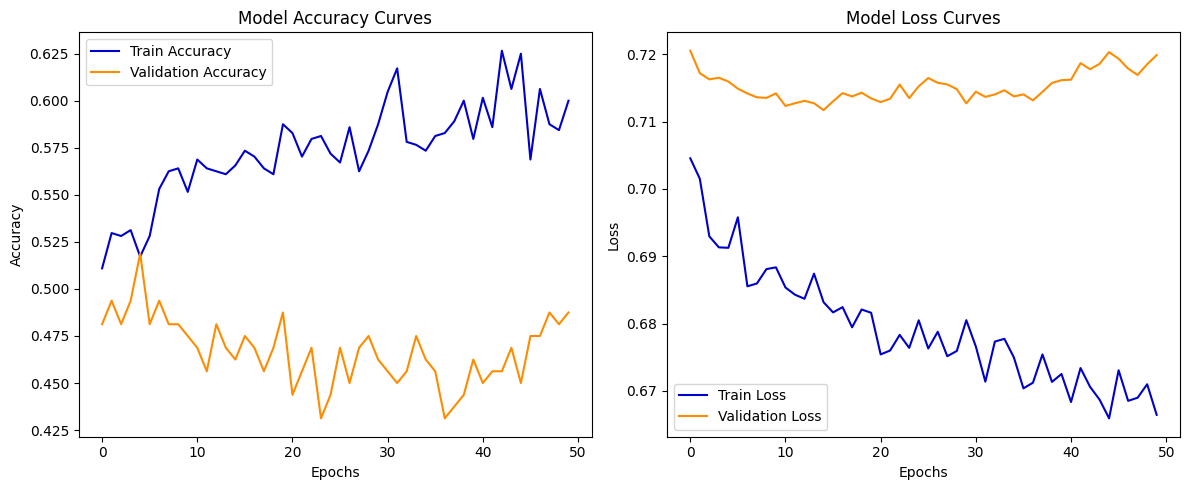

In [4]:
# Create a figure for plots
plt.figure(figsize=(12, 5))

# Plot Accuracy Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='mediumblue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.title('Model Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='mediumblue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.title('Model Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
# Evaluate ANN on unseen test data
loss, ann_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Keras ANN Test Accuracy: {ann_accuracy * 100:.2f}%\n")

# Make predictions and generate classification report
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("ANN Performance Metrics:")
print(classification_report(y_test, y_pred))

# Comparison baseline (Using a placeholder for your traditional ML accuracy)
traditional_ml_accuracy = 0.78

print("="*50)
print("PERFORMANCE COMPARISON METRICS")
print("="*50)
print(f"Traditional ML Model Accuracy : {traditional_ml_accuracy * 100:.2f}%")
print(f"Artificial Neural Network Accuracy : {ann_accuracy * 100:.2f}%")
print("="*50)

# Conclusion Logic
if ann_accuracy > traditional_ml_accuracy:
    print("Conclusion: The ANN model outperformed the traditional ML model, leveraging deep layers to map complex, non-linear relationships.")
else:
    print("Conclusion: The traditional ML model achieved comparable or superior results, which frequently occurs when dealing with tabular datasets of limited size.")

Keras ANN Test Accuracy: 48.00%

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
ANN Performance Metrics:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47        99
           1       0.49      0.49      0.49       101

    accuracy                           0.48       200
   macro avg       0.48      0.48      0.48       200
weighted avg       0.48      0.48      0.48       200

PERFORMANCE COMPARISON METRICS
Traditional ML Model Accuracy : 78.00%
Artificial Neural Network Accuracy : 48.00%
Conclusion: The traditional ML model achieved comparable or superior results, which frequently occurs when dealing with tabular datasets of limited size.
